# 0️⃣ Set-up

## Libs

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import os
import random
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='keras.src.trainers.data_adapters.py_dataset_adapter')

# 1️⃣ Data Loading

## Load

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 12

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],          # new
    channel_shift_range=20,                # new (adjust based on your images)
    fill_mode='nearest',
    validation_split=0.1
)

# Validation generator (only rescaling)
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = train_datagen.flow_from_directory(
    '../data/Train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=123
)

val_gen = val_datagen.flow_from_directory(
    '../data/Train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=123
)

Found 855 images belonging to 6 classes.
Found 186 images belonging to 6 classes.


In [4]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    '../data/Test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 34 images belonging to 6 classes.


## Visualizing 

In [5]:
def show_samples(data_dir, classes_to_show=3, images_per_class=5):
    classes = os.listdir(data_dir)
    
    plt.figure(figsize=(15, 8))
    
    for i, cls in enumerate(classes[:classes_to_show]):
        cls_path = os.path.join(data_dir, cls)
        images = os.listdir(cls_path)
        
        for j in range(images_per_class):
            img_path = os.path.join(cls_path, random.choice(images))
            img = Image.open(img_path)
            
            plt.subplot(classes_to_show, images_per_class, i * images_per_class + j + 1)
            plt.imshow(img)
            plt.title(cls)
            plt.axis('off')
    
    plt.tight_layout()
    plt.show()

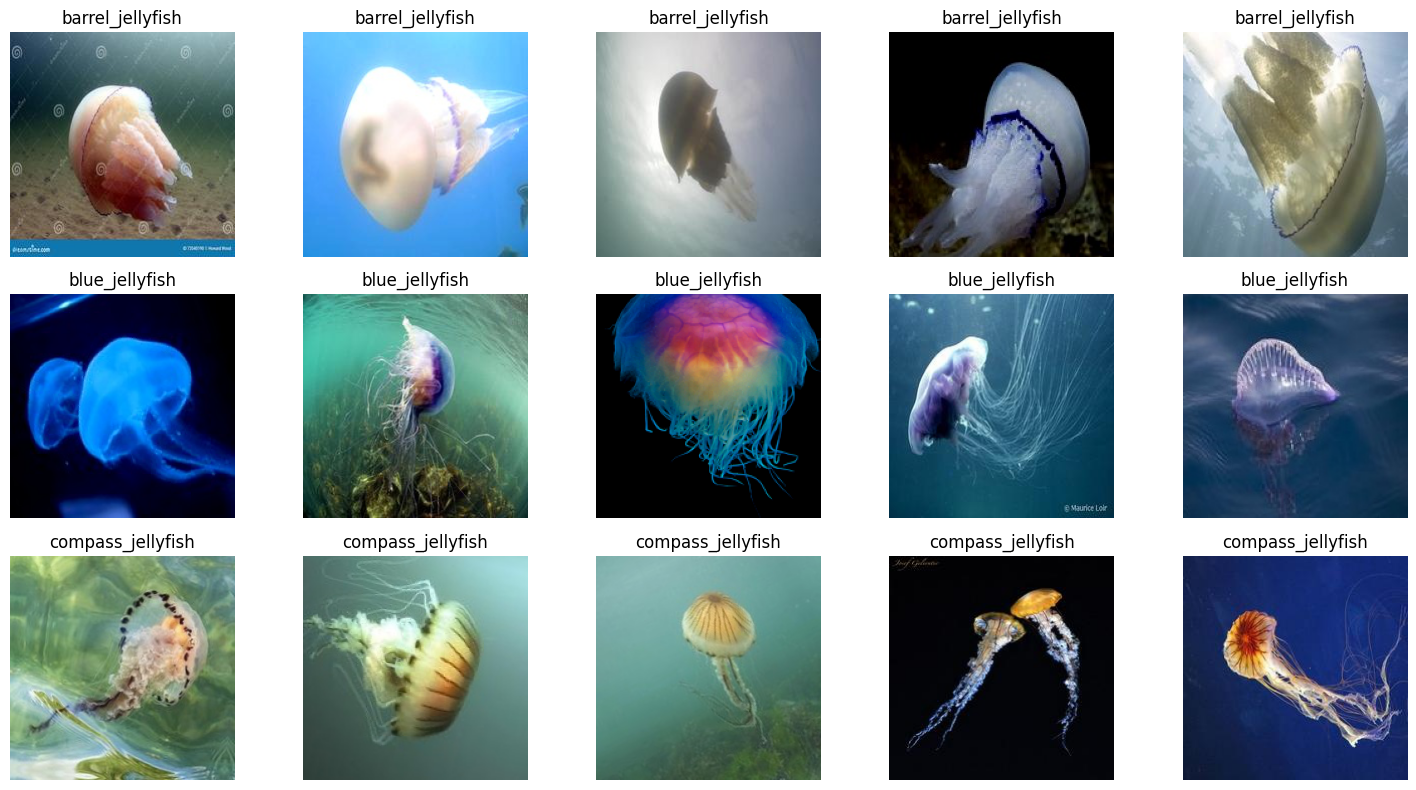

In [6]:
show_samples('../data/Train')

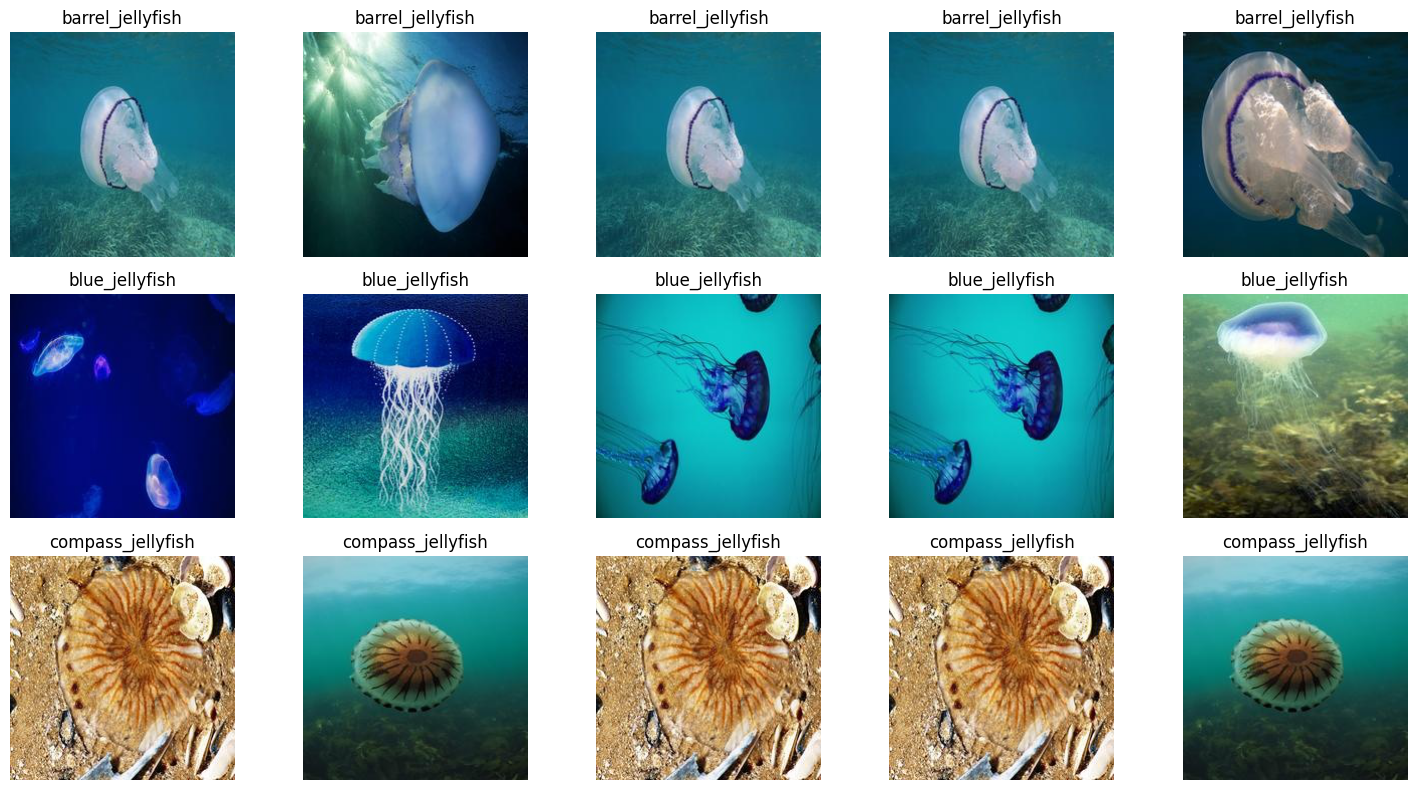

In [7]:
show_samples('../data/Test')

# 2️⃣ Modeling 

## CNN Model Architecture

### keras.layers

In [8]:
models = keras.models
layers = keras.layers
regularizers = keras.regularizers

model = models.Sequential([
    layers.Input(shape=(224,224,3)),
    
    # Block 1
    layers.Conv2D(32, 3, padding='same', activation='relu',
                  kernel_regularizer=regularizers.l2(1e-5)),
    layers.BatchNormalization(),
    layers.Conv2D(32, 3, activation='relu',
                  kernel_regularizer=regularizers.l2(1e-5)),
    layers.MaxPooling2D(2),
    layers.Dropout(0.2),

    # Block 2
    layers.Conv2D(64, 3, padding='same', activation='relu',
                  kernel_regularizer=regularizers.l2(1e-5)),
    layers.BatchNormalization(),
    layers.Conv2D(64, 3, activation='relu',
                  kernel_regularizer=regularizers.l2(1e-5)),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),

    # Block 3 (lighter)
    layers.Conv2D(128, 3, padding='same', activation='relu',
                  kernel_regularizer=regularizers.l2(1e-5)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Dropout(0.3),

    # Classifier
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(1e-5)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(6, activation='softmax')
])

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 222, 222, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 111, 111, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 111, 111, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 109, 109, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 54, 54, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 54, 54, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 27, 27, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 27, 27, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             7

 Total params: 158,118 (617.65 KB)

 Trainable params: 157,414 (614.90 KB)

 Non-trainable params: 704 (2.75 KB)

### Callbacks

In [10]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=1)
]

### Compile

In [11]:
loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)
model.compile(
    optimizer='adam',  
    loss=loss,
    metrics=['accuracy']
)

### Classes Weight

In [12]:
from sklearn.utils.class_weight import compute_class_weight

# Get class indices from generator
class_indices = train_gen.class_indices
classes = train_gen.classes

# Compute weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)
class_weight_dict = dict(enumerate(class_weights))

print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(1.0106382978723405), 1: np.float64(1.0106382978723405), 2: np.float64(0.9965034965034965), 3: np.float64(0.9965034965034965), 4: np.float64(0.9895833333333334), 5: np.float64(0.9965034965034965)}


## Training

In [13]:
%%time
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=callbacks,
    class_weight=class_weight_dict   
)

Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 49s 637ms/step - accuracy: 0.2560 - loss: 2.2040 - val_accuracy: 0.1667 - val_loss: 1.8494 - learning_rate: 0.0010
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 46s 635ms/step - accuracy: 0.3094 - loss: 1.9551 - val_accuracy: 0.1720 - val_loss: 1.9441 - learning_rate: 0.0010
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 46s 643ms/step - accuracy: 0.3340 - loss: 1.9173 - val_accuracy: 0.2043 - val_loss: 1.8018 - learning_rate: 0.0010
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 46s 640ms/step - accuracy: 0.3623 - loss: 1.8092 - val_accuracy: 0.3011 - val_loss: 1.7170 - learning_rate: 0.0010
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 46s 638ms/step - accuracy: 0.2972 - loss: 1.8396 - val_accuracy: 0.2796 - val_loss: 1.7438 - learning_rate: 0.0010
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 47s 654ms/step - accuracy: 0.3736 - loss: 1.7076 - val_accuracy: 0.3925 - val_loss: 1.5610 - learning_rate: 0.0010
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 46s 643ms/step - accuracy: 0.4101 - loss: 1.

### Evaluation

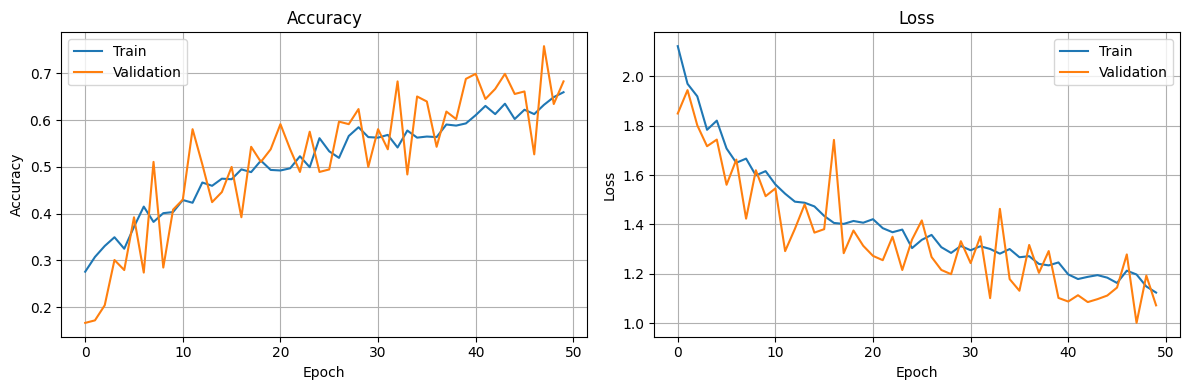

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
ax[0].plot(history.history['accuracy'], label='Train')
ax[0].plot(history.history['val_accuracy'], label='Validation')
ax[0].set_title('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()
ax[0].grid()

# Loss
ax[1].plot(history.history['loss'], label='Train')
ax[1].plot(history.history['val_loss'], label='Validation')
ax[1].set_title('Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()

## Evaluate On Test

In [15]:
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test accuracy: {test_acc:.4f}')

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.5858 - loss: 1.2293
Test accuracy: 0.5882


### Predict 

In [16]:
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())   # e.g., ['class0', 'class1', ...]

# Predict probabilities
predictions = model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
class_names = list(test_generator.class_indices.keys())

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step


### Confusion Matrix

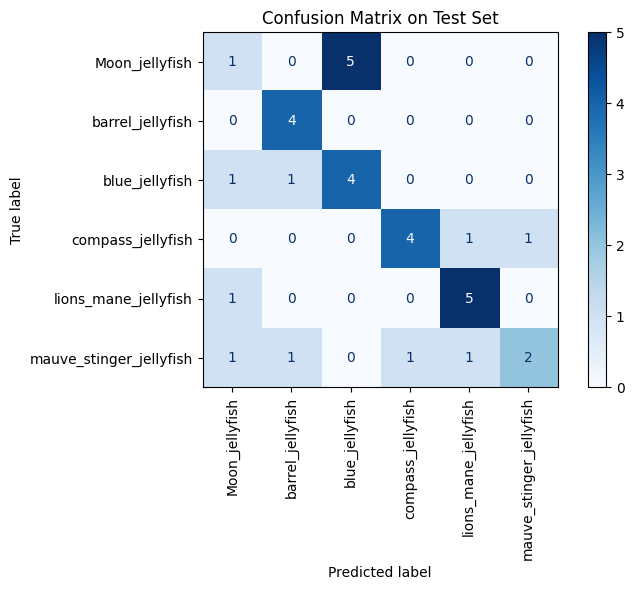


Classification Report:
                         precision    recall  f1-score   support

         Moon_jellyfish       0.25      0.17      0.20         6
       barrel_jellyfish       0.67      1.00      0.80         4
         blue_jellyfish       0.44      0.67      0.53         6
      compass_jellyfish       0.80      0.67      0.73         6
   lions_mane_jellyfish       0.71      0.83      0.77         6
mauve_stinger_jellyfish       0.67      0.33      0.44         6

               accuracy                           0.59        34
              macro avg       0.59      0.61      0.58        34
           weighted avg       0.59      0.59      0.57        34



In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Display using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix on Test Set')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_names))

### Predict VS True

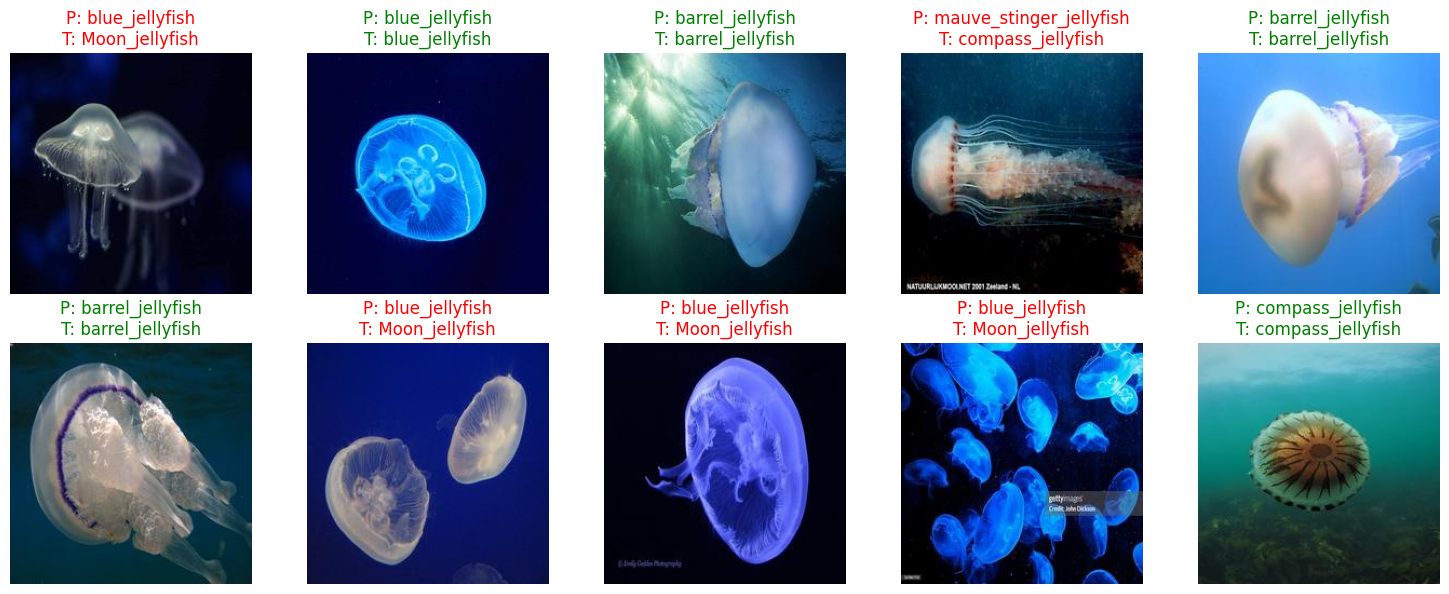

In [18]:
# Get total number of samples and batch size
n_samples = len(test_generator.labels)        # or len(test_generator.classes)
batch_size = test_generator.batch_size

# 3. Randomly select 10 indices
indices = np.random.choice(n_samples, 10, replace=False)

# 4. Create subplots
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

# 5. For each index, fetch the corresponding image from the generator
for i, global_idx in enumerate(indices):
    ax = axes[i]
    
    # Determine which batch contains this image and its position inside the batch
    batch_idx = global_idx // batch_size
    within_idx = global_idx % batch_size
    
    # Get the batch (resets generator to avoid mixing? but we access directly)
    # Note: test_generator[batch_idx] returns (batch_images, batch_labels)
    batch_images, batch_labels = test_generator[batch_idx]
    
    # Extract the specific image and its true label
    image = batch_images[within_idx]           # shape (224,224,3), already normalized
    true_label_idx = true_classes[global_idx]  # from global true array
    pred_label_idx = predicted_classes[global_idx]
    
    true_name = class_names[true_label_idx]
    pred_name = class_names[pred_label_idx]
    
    # Display
    ax.imshow(image)
    color = 'green' if pred_label_idx == true_label_idx else 'red'
    ax.set_title(f"P: {pred_name}\nT: {true_name}", color=color)
    ax.axis('off')

# Hide any extra subplots (if fewer than 10 indices)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()